In [23]:
import numpy as np
import os
import torch
%load_ext autoreload
%autoreload 2
    
directory1 = '../datasets/train_global'
directory2 = '../datasets/test_global'
if not os.path.exists(directory1):
    os.makedirs(directory1)
if not os.path.exists(directory2):
    os.makedirs(directory2)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
from smalldiffusion.data import npyData
from torch.utils.data import DataLoader
from smalldiffusion.diffusion import ScheduleLogLinear
from accelerate import Accelerator
a = Accelerator()
print(a.state)

# wave = np.load('../datasets/wave_mean.npy')
# forcing = np.load('../datasets/forcing.npy')    

# # Remove the top and bottom of latitude padding
# np.save('../datasets/train_global/wave.npy', wave[:401, :, 1:-2])
# np.save('../datasets/train_global/forcing.npy', forcing[:401, :, 1:-2])
# np.save('../datasets/test_global/wave.npy', wave[402:, :, 1:-2])
# np.save('../datasets/test_global/forcing.npy', forcing[402:, :, 1:-2])

# mask = np.load('../datasets/mask.npy')
# np.save('../datasets/train_global/mask.npy', mask[1:-2])
# np.save('../datasets/test_global/mask.npy', mask[1:-2])

### Some parameters
train_batch_size = 8
sample_batch_size = 2
epochs = 10

Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: no



In [54]:
from torchvision import transforms as tf
class FillNaN(object):
    """ Replace NaNs with zeros (or any value). """
    def __init__(self, value=0.0):
        self.value = value

    def __call__(self, tensor):
        return torch.nan_to_num(tensor, nan=self.value)

class Mask(object):
    """ Mask land. Let's say it works only on C*H*W. """
    def __init__(self, mask):
        self.mask = mask
    def __call__(self, tensor):
        return tensor * self.mask.to(tensor.device)
        
class npyDataResized(npyData):
    def __init__(self, *args, resize_x=(320,320), resize_f=(320,320), **kwargs):
        super().__init__(*args, **kwargs)  # call original __init__

        self.mask_original = torch.tensor(self.mask.astype(bool))[None, :, :].float()
        self.mask_resized = tf.Resize(resize_x)(self.mask_original)
        self.original_H = self.X.shape[2]
        self.original_W = self.X.shape[3]
        
        # Patch the transforms
        self.tf_x = tf.Compose([
            FillNaN(0.0),
            tf.Resize(resize_x),
            tf.Normalize(self.meanx.tolist(), self.stdx.tolist()),
            Mask(self.mask_resized)
        ])
        self.tf_f = tf.Compose([
            FillNaN(0.0),
            tf.Resize(resize_f),
            tf.Normalize(self.meanf.tolist(), self.stdf.tolist()),
            Mask(self.mask_resized)
        ])
        # Inverse transforms
        self.inv_tf_x = tf.Compose([
            tf.Resize((self.original_H, self.original_W)),
            tf.Normalize(mean=[0]*len(self.meanx), std=(1/self.stdx).tolist()),
            tf.Normalize(mean=(-self.meanx).tolist(), std=[1]*len(self.stdx)),
            Mask(self.mask_original)
        ])
        self.inv_tf_f = tf.Compose([
            tf.Resize((self.original_H, self.original_W)),
            tf.Normalize(mean=[0]*len(self.meanf), std=(1/self.stdf).tolist()),
            tf.Normalize(mean=(-self.meanf).tolist(), std=[1]*len(self.stdf)),
            Mask(self.mask_original)
        ])

In [55]:
train = npyDataResized('../datasets/train_global/wave.npy', '../datasets/train_global/forcing.npy', '../datasets/train_global/mask.npy', 
                       resize_x=(320,320), resize_f=(320,320), compute_stats=True)
test = npyDataResized('../datasets/test_global/wave.npy', '../datasets/test_global/forcing.npy', '../datasets/test_global/mask.npy', 
                      resize_x=(320,320), resize_f=(320,320), compute_stats=False, meanx=train.meanx, stdx=train.stdx, meanf=train.meanf, stdf=train.stdf)
# print(train.meanx)

loader = DataLoader(train, batch_size=train_batch_size, shuffle=True)
# Used for generating samples during training
loader_test = DataLoader(test, batch_size=sample_batch_size, shuffle=True)
loader_test_iter = iter(loader_test)

schedule = ScheduleLogLinear(sigma_min=0.01, sigma_max=20, N=80)

Computing dataset mean and std...


### Train (either from scratch or resume)

In [14]:
from smalldiffusion.model_unet import myUnet
from smalldiffusion.model import Scaled

model = Scaled(myUnet)(in_dim=320, in_ch=4, out_ch=4, ch=64, precond_ch=3, ch_mult=(1, 2, 2), attn_resolutions=(16,))
mask_batched = train.mask_resized[None, :, :, :]

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

RESUME = True
weights_file = '../run/global/checkpoint.pth'
    
if RESUME:
    model.load_state_dict(torch.load(weights_file, map_location='cpu'))    

model, optimizer, loader = a.prepare(model, optimizer, loader)

In [16]:
from smalldiffusion.diffusion import ScheduleLogLinear, samples, my_training_loop
from torch_ema import ExponentialMovingAverage as EMA
log_file = open("../run/global/loss_log.txt", "w")
ema = EMA(model.parameters(), decay=0.999)
ema.to(a.device)
for ns in my_training_loop(loader, model, schedule, epochs=epochs, lr=7e-4, accelerator=a, conditional=True, mask=mask_tensor):
    log_file.write(f"{ns.loss.item():.5}\n")
    ns.pbar.set_description(f'Loss={ns.loss.item():.5}')
    ema.update()
log_file.close()

### Evaluation

In [56]:
loader_test = DataLoader(test, batch_size=2, shuffle=True)
loader_iter = iter(loader_test) 
x, f = next(loader_iter)
*xt, x0 = samples(model, schedule.sample_sigmas(80), gam=1.6, batchsize=2, accelerator=a, cond=f[:2], mask=mask_batched)

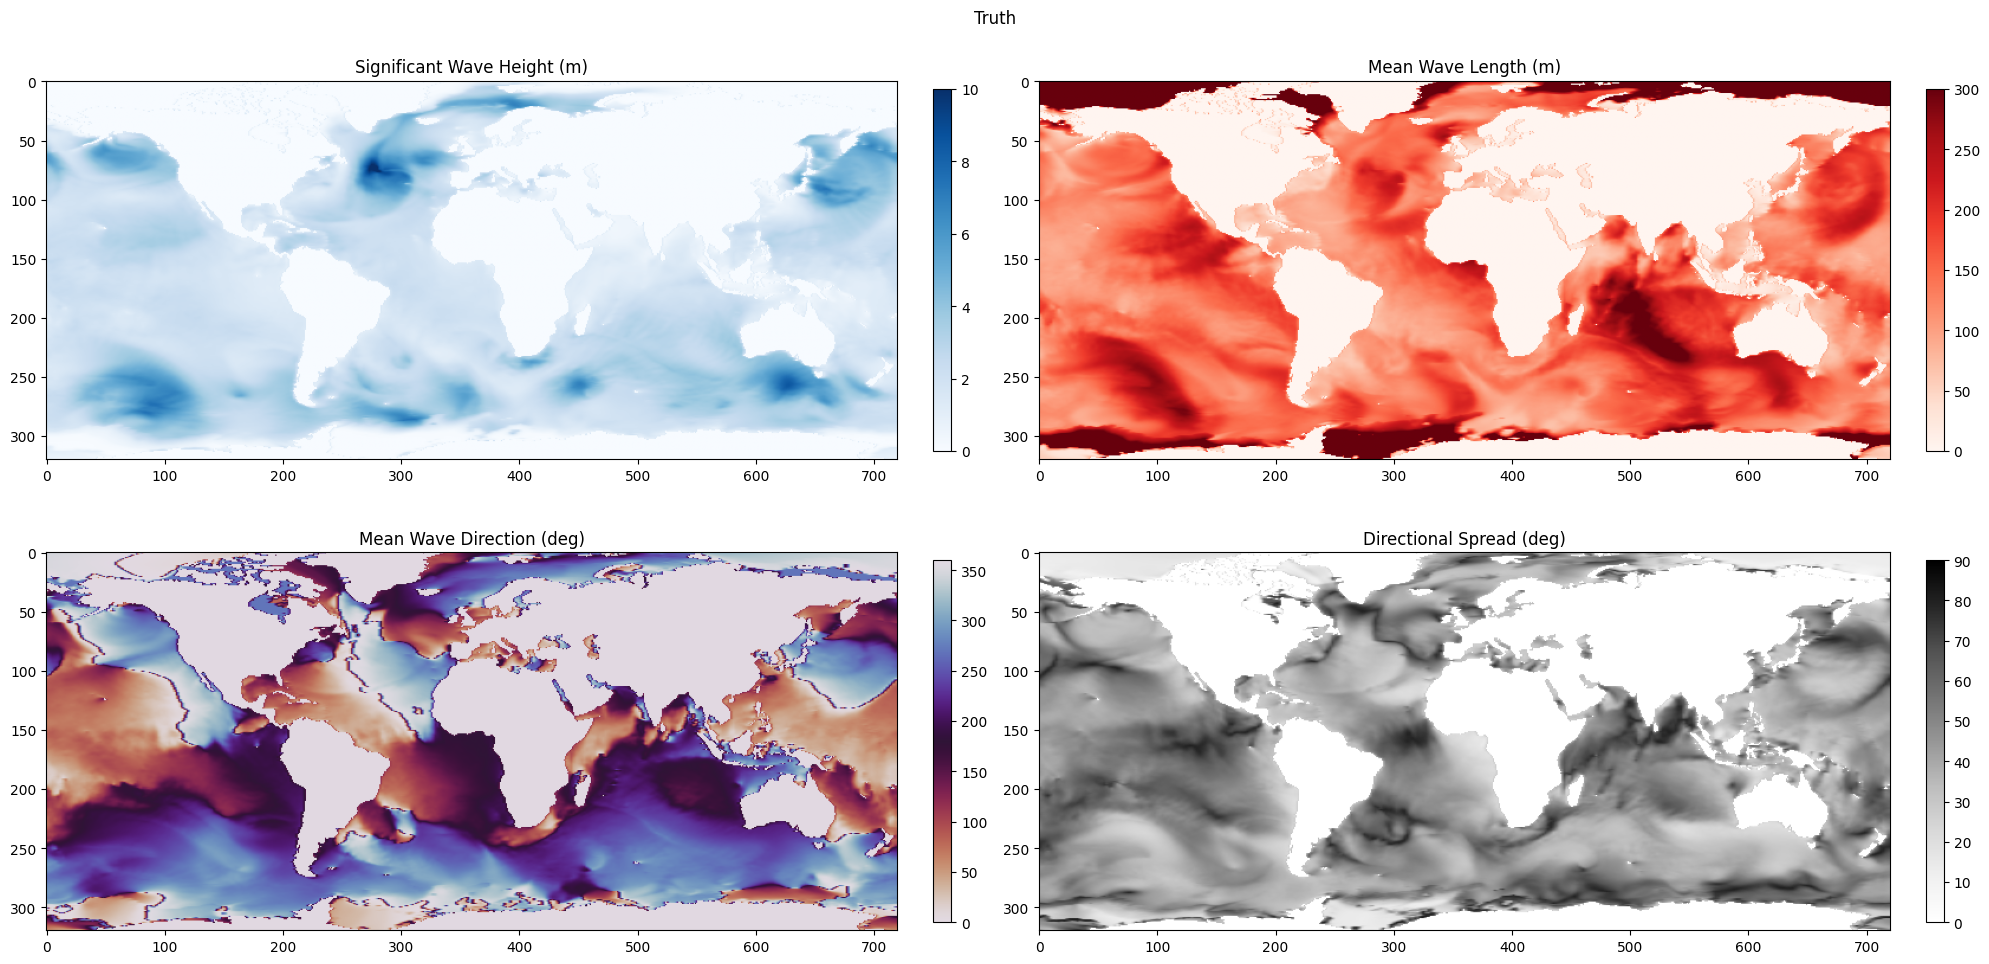

In [74]:
from matplotlib import pyplot as plt
x_ = train.inv_tf_x(x[0])

fig, axes = plt.subplots(2, 2, figsize=(20, 10))
img0 = axes[0,0].imshow(x_.cpu().numpy()[0,::-1], vmin=0, vmax=10, cmap='Blues')
img1 = axes[0,1].imshow(x_.cpu().numpy()[1,::-1], vmin=0, vmax=300, cmap='Reds')
img2 = axes[1,0].imshow(x_.cpu().numpy()[2,::-1], vmin=0, vmax=360, cmap='twilight_r')
img3 = axes[1,1].imshow(x_.cpu().numpy()[3,::-1], vmin=0, vmax=90, cmap='Greys')
plt.colorbar(img0, ax=axes[0,0], fraction=0.02, pad=0.04)
plt.colorbar(img1, ax=axes[0,1], fraction=0.02, pad=0.04)
plt.colorbar(img2, ax=axes[1,0], fraction=0.02, pad=0.04)
plt.colorbar(img3, ax=axes[1,1], fraction=0.02, pad=0.04)
axes[0,0].set_title('Significant Wave Height (m)')
axes[0,1].set_title('Mean Wave Length (m)')
axes[1,0].set_title('Mean Wave Direction (deg)')
axes[1,1].set_title('Directional Spread (deg)')

plt.suptitle('Truth')
plt.tight_layout()
plt.show()

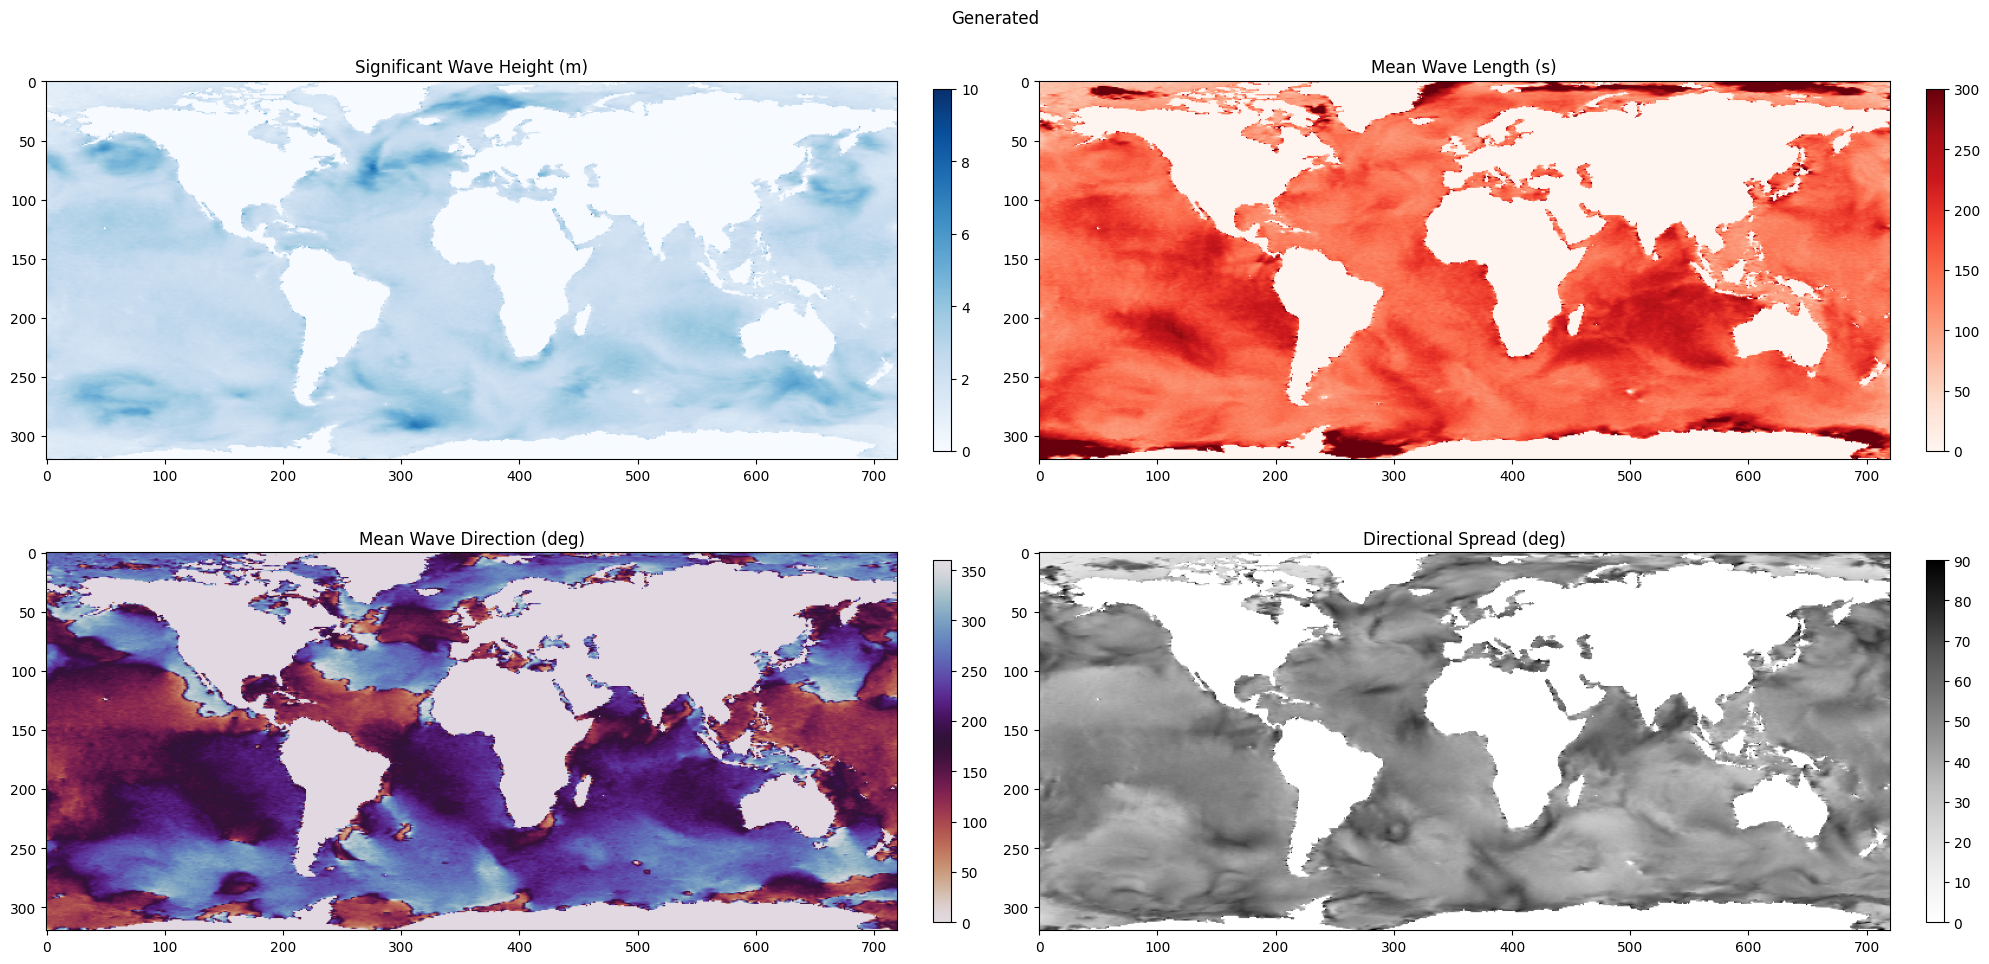

In [75]:
from matplotlib import pyplot as plt
x_ = train.inv_tf_x(x0[0])

fig, axes = plt.subplots(2, 2, figsize=(20, 10))
img0 = axes[0,0].imshow(x_.cpu().numpy()[0,::-1], vmin=0, vmax=10, cmap='Blues')
img1 = axes[0,1].imshow(x_.cpu().numpy()[1,::-1], vmin=0, vmax=300, cmap='Reds')
img2 = axes[1,0].imshow(x_.cpu().numpy()[2,::-1], vmin=0, vmax=360, cmap='twilight_r')
img3 = axes[1,1].imshow(x_.cpu().numpy()[3,::-1], vmin=0, vmax=90, cmap='Greys')
plt.colorbar(img0, ax=axes[0,0], fraction=0.02, pad=0.04)
plt.colorbar(img1, ax=axes[0,1], fraction=0.02, pad=0.04)
plt.colorbar(img2, ax=axes[1,0], fraction=0.02, pad=0.04)
plt.colorbar(img3, ax=axes[1,1], fraction=0.02, pad=0.04)
axes[0,0].set_title('Significant Wave Height (m)')
axes[0,1].set_title('Mean Wave Length (s)')
axes[1,0].set_title('Mean Wave Direction (deg)')
axes[1,1].set_title('Directional Spread (deg)')

plt.suptitle('Generated')
plt.tight_layout()
plt.show()

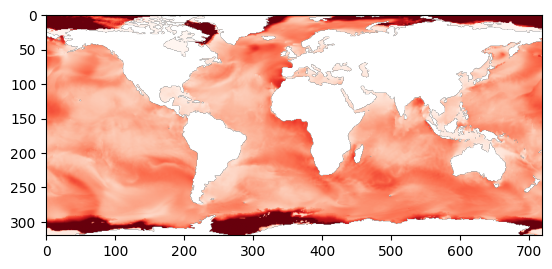

In [58]:
from matplotlib import pyplot as plt
x_ = np.load('../datasets/test_global/wave.npy')[0]
plt.imshow(x_[1,::-1], vmax=400, vmin=0, cmap='Reds')

In [32]:
from torch import nn
from typing import Optional, Union, Tuple
from itertools import pairwise
@torch.no_grad()
def samples(model      : nn.Module,
            sigmas     : torch.FloatTensor, # Iterable with N+1 values for N sampling steps
            gam        : float = 1.,        # Suggested to use gam >= 1
            mu         : float = 0.,        # Requires mu in [0, 1)
            cfg_scale  : int = 0.,          # 0 means no classifier-free guidance
            batchsize  : int = 1,
            xt         : Optional[torch.FloatTensor] = None,
            cond       : Optional[torch.Tensor] = None,
            accelerator: Optional[Accelerator] = None, 
            mask       : Optional[torch.FloatTensor] = None):
    model.eval()
    accelerator = accelerator or Accelerator()
    # Enforce mask fif provided (mask shape: (1, 1, H, W))
    if xt is None:
        if mask is not None:
            xt = model.rand_input(batchsize).to(accelerator.device) * sigmas[0] * mask.to(accelerator.device)
        else:
            xt = model.rand_input(batchsize).to(accelerator.device) * sigmas[0]   
    if cond is not None:
        assert cond.shape[0] == xt.shape[0], 'cond must have same shape as x!'
        cond = cond.to(xt.device)
    eps = None
    for i, (sig, sig_prev) in enumerate(pairwise(sigmas)):
        eps_prev, eps = eps, model.predict_eps_cfg(xt, sig.to(xt), cond, cfg_scale)
        eps_av = eps * gam + eps_prev * (1-gam)  if i > 0 else eps
        # Mask here
        if mask is not None:
            eps_av = eps_av * mask.to(eps_av.device)
        sig_p = (sig_prev/sig**mu)**(1/(1-mu)) # sig_prev == sig**mu sig_p**(1-mu)
        eta = (sig_prev**2 - sig_p**2).sqrt()
        # Mask here
        if mask is not None:
            xt = xt - (sig - sig_p) * eps_av + eta * model.rand_input(xt.shape[0]).to(xt) * mask.to(xt.device)
        else:
            xt = xt - (sig - sig_p) * eps_av + eta * model.rand_input(xt.shape[0]).to(xt) 
        yield xt

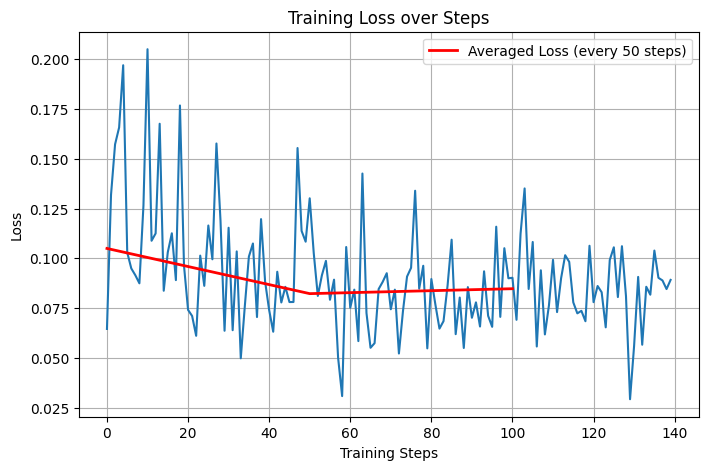

In [22]:
### Read in loss log and plot
losses = []
with open("../run/global/loss_log.txt", "r") as log_file:
    for line in log_file:
        losses.append(float(line.strip()))  
    
plt.figure(figsize=(8,5))
plt.plot(losses)
# Plot averaged loss every 50 steps
avg_losses = [np.mean(losses[i:i+50]) for i in range(0, len(losses), 50)]
plt.plot(range(0, len(losses), 50), avg_losses, color='red', linewidth=2, label='Averaged Loss (every 50 steps)')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training Loss over Steps')
plt.legend()
plt.grid()

### Unit tests

In [46]:
# Check dimensional consistency
from smalldiffusion.diffusion import generate_train_sample

mask_train = torch.tensor(train.mask.astype(bool))[None, None, :, :]
mask_train = tf.Resize((320,320))(mask_train)

test_x = torch.rand([4,4,320,320])
test_f = torch.rand([4,3,320,320])
x0, sigma, eps, cond = generate_train_sample([test_x, test_f], schedule, conditional=True)
# insert mask for noise:
eps = eps * mask_train
y = model.forward(x0 + sigma * eps, sigma, cond=cond)

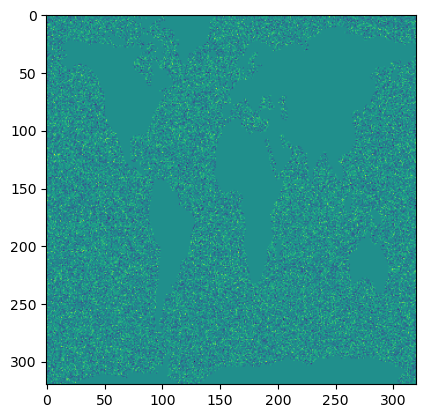

In [47]:
plt.imshow(eps.numpy()[0,0,::-1])

In [11]:
loader= DataLoader(train, batch_size=2, shuffle=True)
loader_iter = iter(loader) 
x, f = next(loader_iter)

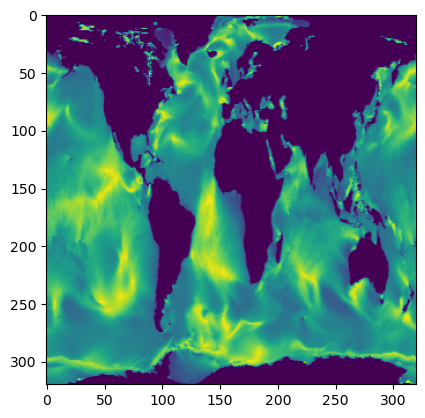

In [15]:
from matplotlib import pyplot as plt
plt.imshow(x.numpy()[0,3,::-1])

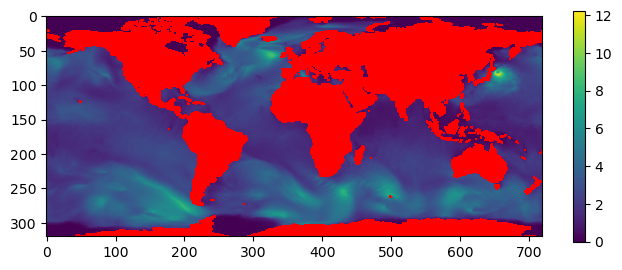

In [48]:
plt.figure(figsize=(8,3))

cmap = plt.cm.viridis.copy()
cmap.set_bad(color='red')

plt.imshow(train.X[0,0,::-1], cmap=cmap)
plt.colorbar()

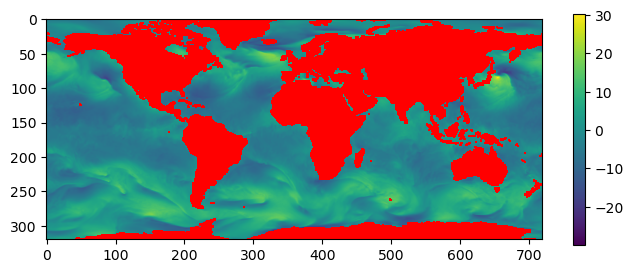

In [49]:
plt.figure(figsize=(8,3))

cmap = plt.cm.viridis.copy()
cmap.set_bad(color='red')

plt.imshow(train.F[0,0,::-1], cmap=cmap)
plt.colorbar()